# Manufacturing Quality Control Statistical Analysis - Student Worksheet

Complete the missing code sections to perform a comprehensive SPC analysis


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Manufacturing Quality Control Statistical Analysis - Student Worksheet")
print("=" * 70)

Manufacturing Quality Control Statistical Analysis - Student Worksheet


In [13]:
# ============================================================================
# SECTION 1: DATA GENERATION AND EXPLORATION
# ============================================================================

print("\n📊 SECTION 1: Data Generation and Exploration")
print("-" * 50)

# TODO 1.1: Set random seed for reproducibility
# HINT: Use np.random.seed() with seed value 42
np.random.seed(42)

# Process parameters for shaft diameter manufacturing
target_diameter = 10.0  # mm - target dimension
process_std = 0.05     # mm - process standard deviation
n_samples = 200        # number of measurements

# TODO 1.2: Generate baseline process data (in-control condition)
# HINT: Use np.random.normal() with target_diameter, process_std, and n_samples
baseline_measurements = np.random.normal(target_diameter, process_std, n_samples)

# Simulate process problems starting at sample 150
drift_start = 150

# TODO 1.3: Generate drift measurements (out-of-control condition)
# HINT: Use target_diameter + 0.15 for mean and process_std * 1.2 for std, 50 samples
drift_measurements = np.random.normal(target_diameter + 0.15, process_std * 1.2, 50)

# TODO 1.4: Combine the baseline and drift data
# HINT: Use np.concatenate() to join baseline_measurements[:drift_start] and drift_measurements
all_measurements = np.concatenate([baseline_measurements[:drift_start], drift_measurements])

sample_numbers = np.arange(1, len(all_measurements) + 1)

# Create DataFrame
df = pd.DataFrame({
    'Sample_Number': sample_numbers,
    'Diameter_mm': all_measurements,
    'Shift': ['Day' if i < 100 else 'Night' if i < 200 else 'Weekend' for i in range(len(all_measurements))],
    'Operator': [f'Operator_{(i//25) % 4 + 1}' for i in range(len(all_measurements))]
})

print("Dataset Overview:")
print(df.head(10))

# TODO 1.5: Print basic statistics for the diameter measurements
# HINT: Use .describe() method on the Diameter_mm column
print(f"\nBasic statistics:")
print(df['Diameter_mm'].describe())



📊 SECTION 1: Data Generation and Exploration
--------------------------------------------------
Dataset Overview:
   Sample_Number  Diameter_mm Shift    Operator
0              1    10.024836   Day  Operator_1
1              2     9.993087   Day  Operator_1
2              3    10.032384   Day  Operator_1
3              4    10.076151   Day  Operator_1
4              5     9.988292   Day  Operator_1
5              6     9.988293   Day  Operator_1
6              7    10.078961   Day  Operator_1
7              8    10.038372   Day  Operator_1
8              9     9.976526   Day  Operator_1
9             10    10.027128   Day  Operator_1

Basic statistics:
count    200.000000
mean      10.036677
std        0.087958
min        9.869013
25%        9.976667
50%       10.014963
75%       10.078414
max       10.381164
Name: Diameter_mm, dtype: float64


In [14]:
# ============================================================================
# SECTION 2: CONTROL CHART CALCULATIONS
# ============================================================================

print("\n📈 SECTION 2: Control Chart Setup")
print("-" * 40)

def calculate_control_limits(data):
    """Calculate control limits for X-bar chart"""
    # TODO 2.1: Calculate the mean of the data
    # HINT: Use np.mean()
    mean = np.mean(data)
    
    # TODO 2.2: Calculate the standard deviation with ddof=1
    # HINT: Use np.std() with ddof parameter
    std = np.std(data, ddof=1)
    
    # TODO 2.3: Calculate Upper Control Limit (mean + 3*std)
    ucl = mean + 3 * std
    
    # TODO 2.4: Calculate Lower Control Limit (mean - 3*std)
    lcl = mean - 3 * std
    
    return ucl, mean, lcl

# TODO 2.5: Calculate control limits using only the first 'drift_start' samples
# HINT: Use df['Diameter_mm'][:drift_start] as the input data
UCL, CL, LCL = calculate_control_limits(df['Diameter_mm'][:drift_start])

print(f"Control Chart Parameters (based on first {drift_start} samples):")
print(f"Upper Control Limit (UCL): {UCL:.4f} mm")
print(f"Center Line (CL):          {CL:.4f} mm") 
print(f"Lower Control Limit (LCL): {LCL:.4f} mm")


📈 SECTION 2: Control Chart Setup
----------------------------------------
Control Chart Parameters (based on first 150 samples):
Upper Control Limit (UCL): 10.1372 mm
Center Line (CL):          9.9959 mm
Lower Control Limit (LCL): 9.8545 mm



📊 SECTION 3: Control Chart Creation
------------------------------------------


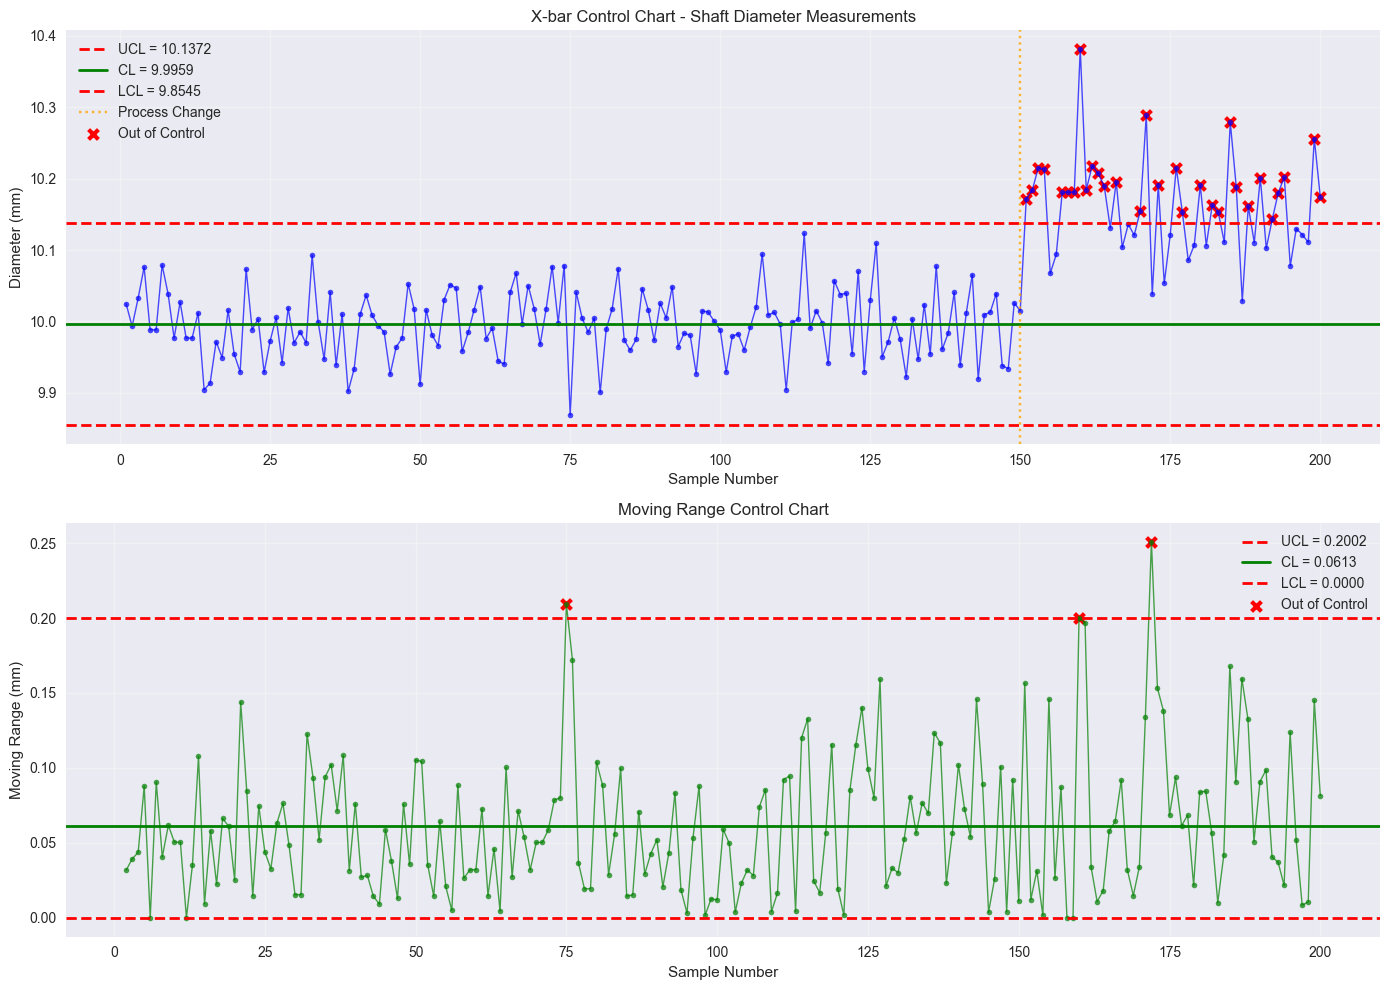

In [15]:
# ============================================================================
# SECTION 3: CONTROL CHART VISUALIZATION
# ============================================================================

print("\n📊 SECTION 3: Control Chart Creation")
print("-" * 42)

# TODO 3.1: Create a figure with 2 subplots (2 rows, 1 column)
# HINT: Use plt.subplots(rows, cols, figsize=(width, height))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# X-bar Control Chart
# TODO 3.2: Plot the diameter measurements vs sample numbers
# HINT: Use ax1.plot() with Sample_Number and Diameter_mm columns
ax1.plot(df['Sample_Number'], df['Diameter_mm'], 'bo-', markersize=4, linewidth=1, alpha=0.7)

# TODO 3.3: Add horizontal lines for control limits
# HINT: Use ax1.axhline() for each limit (UCL, CL, LCL)
ax1.axhline(y=UCL, color='red', linestyle='--', linewidth=2, label=f'UCL = {UCL:.4f}')
ax1.axhline(y=CL, color='green', linestyle='-', linewidth=2, label=f'CL = {CL:.4f}')
ax1.axhline(y=LCL, color='red', linestyle='--', linewidth=2, label=f'LCL = {LCL:.4f}')

ax1.axvline(x=drift_start, color='orange', linestyle=':', alpha=0.8, label='Process Change')

# TODO 3.4: Identify out-of-control points
# HINT: Create a boolean mask where diameter is > UCL or < LCL
out_of_control = (df['Diameter_mm'] > UCL) | (df['Diameter_mm'] < LCL)

ax1.scatter(df[out_of_control]['Sample_Number'], df[out_of_control]['Diameter_mm'], 
           color='red', s=50, marker='x', linewidth=3, label='Out of Control')

ax1.set_xlabel('Sample Number')
ax1.set_ylabel('Diameter (mm)')
ax1.set_title('X-bar Control Chart - Shaft Diameter Measurements')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Moving Range Chart
# TODO 3.5: Calculate moving ranges (absolute difference between consecutive measurements)
# HINT: Use np.abs() and np.diff() on the diameter column
moving_ranges = np.abs(np.diff(df['Diameter_mm']))

# TODO 3.6: Calculate moving range control limits
# HINT: Mean of moving ranges, UCL = 3.267 * mean, LCL = 0
mr_mean = np.mean(moving_ranges)
mr_ucl = 3.267 * mr_mean
mr_lcl = 0

ax2.plot(df['Sample_Number'][1:], moving_ranges, 'go-', markersize=4, linewidth=1, alpha=0.7)
ax2.axhline(y=mr_ucl, color='red', linestyle='--', linewidth=2, label=f'UCL = {mr_ucl:.4f}')
ax2.axhline(y=mr_mean, color='green', linestyle='-', linewidth=2, label=f'CL = {mr_mean:.4f}')
ax2.axhline(y=mr_lcl, color='red', linestyle='--', linewidth=2, label=f'LCL = {mr_lcl:.4f}')

# TODO 3.7: Identify out-of-control moving ranges
# HINT: Moving ranges greater than mr_ucl
mr_out_of_control = moving_ranges > mr_ucl

ax2.scatter(df['Sample_Number'][1:][mr_out_of_control], moving_ranges[mr_out_of_control], 
           color='red', s=50, marker='x', linewidth=3, label='Out of Control')

ax2.set_xlabel('Sample Number')
ax2.set_ylabel('Moving Range (mm)')
ax2.set_title('Moving Range Control Chart')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# ============================================================================
# SECTION 4: PROCESS CAPABILITY ANALYSIS
# ============================================================================

print("\n🎯 SECTION 4: Process Capability Analysis")
print("-" * 45)

# Define specification limits
USL = 10.20  # Upper Specification Limit
LSL = 9.80   # Lower Specification Limit
nominal = 10.0

# TODO 4.1: Calculate process statistics for in-control period
# HINT: Use the first 'drift_start' samples only
process_mean = np.mean(df['Diameter_mm'][:drift_start])
process_std = np.std(df['Diameter_mm'][:drift_start], ddof=1)

# TODO 4.2: Calculate Cp (Process Capability)
# HINT: Cp = (USL - LSL) / (6 * process_std)
Cp = (USL - LSL) / (6 * process_std)

# TODO 4.3: Calculate Cpk components
# HINT: Cpu = (USL - mean) / (3 * std), Cpl = (mean - LSL) / (3 * std)
Cpu = (USL - process_mean) / (3 * process_std)
Cpl = (process_mean - LSL) / (3 * process_std)

# TODO 4.4: Calculate Cpk (minimum of Cpu and Cpl)
# HINT: Use min() function
Cpk = min(Cpu, Cpl)

# Overall performance (using all data)
pp_mean = np.mean(df['Diameter_mm'])
pp_std = np.std(df['Diameter_mm'], ddof=1)

# TODO 4.5: Calculate Pp and Ppk for overall performance
# HINT: Same formulas as Cp and Cpk but using pp_mean and pp_std
Pp = (USL - LSL) / (6 * pp_std)
Ppu = (USL - pp_mean) / (3 * pp_std)
Ppl = (pp_mean - LSL) / (3 * pp_std)
Ppk = min(Ppu, Ppl)

print("Process Capability Analysis:")
print("=" * 30)
print(f"Specification Limits: LSL = {LSL} mm, USL = {USL} mm")
print(f"\nIn-Control Process (first {drift_start} samples):")
print(f"Process Mean: {process_mean:.4f} mm")
print(f"Process Std:  {process_std:.4f} mm")
print(f"Cp  = {Cp:.3f}  (Potential Capability)")
print(f"Cpk = {Cpk:.3f}  (Actual Capability)")

print(f"\nOverall Process Performance (all {len(df)} samples):")
print(f"Pp  = {Pp:.3f}  (Overall Performance)")
print(f"Ppk = {Ppk:.3f}  (Overall Performance Index)")



🎯 SECTION 4: Process Capability Analysis
---------------------------------------------
Process Capability Analysis:
Specification Limits: LSL = 9.8 mm, USL = 10.2 mm

In-Control Process (first 150 samples):
Process Mean: 9.9959 mm
Process Std:  0.0471 mm
Cp  = 1.415  (Potential Capability)
Cpk = 1.386  (Actual Capability)

Overall Process Performance (all 200 samples):
Pp  = 0.758  (Overall Performance)
Ppk = 0.619  (Overall Performance Index)



📊 SECTION 5: Process Distribution Analysis
---------------------------------------------


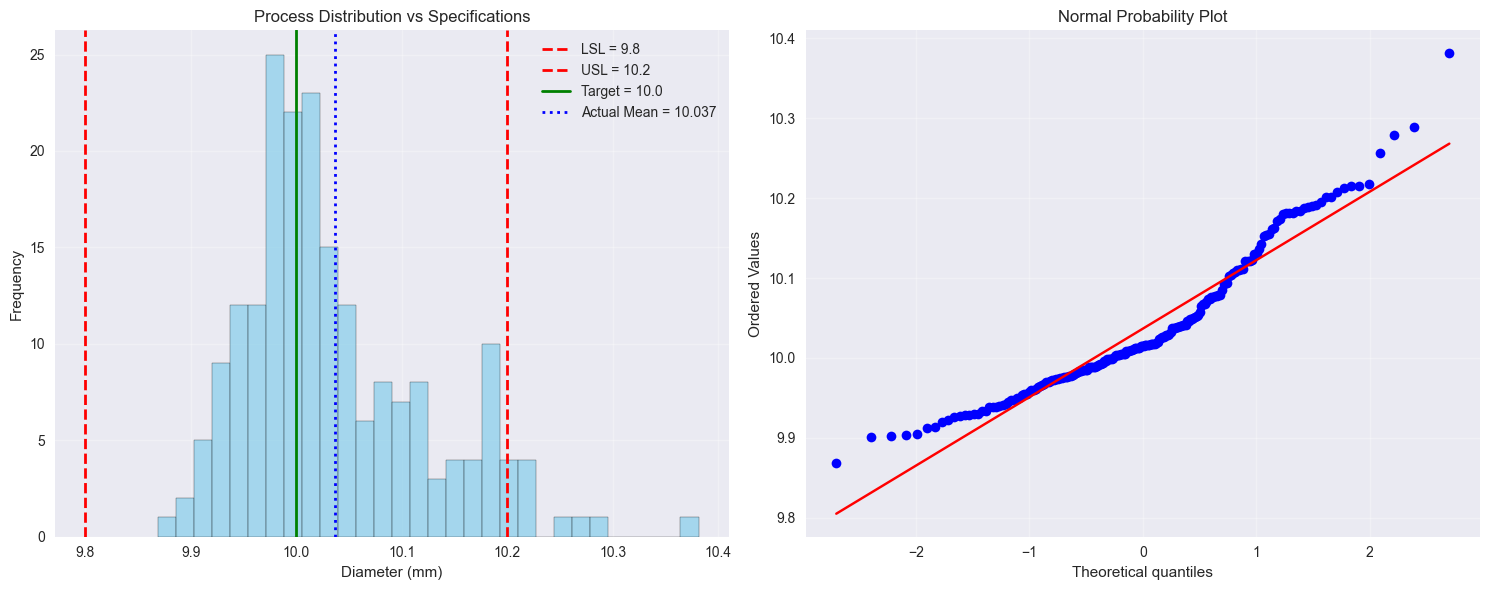

In [17]:
# ============================================================================
# SECTION 5: HISTOGRAM AND DISTRIBUTION ANALYSIS
# ============================================================================

print("\n📊 SECTION 5: Process Distribution Analysis")
print("-" * 45)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# TODO 5.1: Create histogram of diameter measurements
# HINT: Use ax1.hist() with appropriate parameters
ax1.hist(df['Diameter_mm'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')

# TODO 5.2: Add specification limit lines to histogram
# HINT: Use ax1.axvline() for LSL, USL, nominal, and actual mean
ax1.axvline(x=LSL, color='red', linestyle='--', linewidth=2, label=f'LSL = {LSL}')
ax1.axvline(x=USL, color='red', linestyle='--', linewidth=2, label=f'USL = {USL}')
ax1.axvline(x=nominal, color='green', linestyle='-', linewidth=2, label=f'Target = {nominal}')
ax1.axvline(x=np.mean(df['Diameter_mm']), color='blue', linestyle=':', linewidth=2, 
           label=f'Actual Mean = {np.mean(df["Diameter_mm"]):.3f}')

ax1.set_xlabel('Diameter (mm)')
ax1.set_ylabel('Frequency')
ax1.set_title('Process Distribution vs Specifications')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Normal probability plot
stats.probplot(df['Diameter_mm'], dist="norm", plot=ax2)
ax2.set_title('Normal Probability Plot')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# ============================================================================
# SECTION 6: DEFECT RATE ANALYSIS
# ============================================================================

print("\n🚨 SECTION 6: Defect Rate Analysis")
print("-" * 38)

# TODO 6.1: Calculate number of defects in in-control period
# HINT: Count samples outside specification limits (< LSL or > USL)
in_control_defects = np.sum((df['Diameter_mm'][:drift_start] < LSL) | 
                           (df['Diameter_mm'][:drift_start] > USL))

# TODO 6.2: Calculate total defects in entire dataset
total_defects = np.sum((df['Diameter_mm'] < LSL) | (df['Diameter_mm'] > USL))

# TODO 6.3: Calculate defect rates as percentages
# HINT: (defects / total samples) * 100
in_control_defect_rate = (in_control_defects / drift_start) * 100
overall_defect_rate = (total_defects / len(df)) * 100

print(f"Defect Rate Analysis:")
print("=" * 25)
print(f"In-control period defects: {in_control_defects} out of {drift_start} ({in_control_defect_rate:.2f}%)")
print(f"Overall defects: {total_defects} out of {len(df)} ({overall_defect_rate:.2f}%)")

# TODO 6.4: Calculate theoretical defect rate using normal distribution
# HINT: Use stats.norm.cdf() for lower tail and (1 - stats.norm.cdf()) for upper tail
theoretical_defect_rate = (stats.norm.cdf(LSL, process_mean, process_std) + 
                          (1 - stats.norm.cdf(USL, process_mean, process_std))) * 100

print(f"Theoretical defect rate (in-control): {theoretical_defect_rate:.3f}%")



🚨 SECTION 6: Defect Rate Analysis
--------------------------------------
Defect Rate Analysis:
In-control period defects: 0 out of 150 (0.00%)
Overall defects: 11 out of 200 (5.50%)
Theoretical defect rate (in-control): 0.002%


In [19]:
# ============================================================================
# SECTION 7: INTERPRETATION AND RECOMMENDATIONS
# ============================================================================

print("\n📋 SECTION 7: Results Interpretation")
print("-" * 42)

def interpret_capability(cpk_value):
    """Interpret process capability index"""
    # TODO 7.1: Complete the capability interpretation function
    # HINT: Use if-elif-else statements with the provided thresholds
    if cpk_value >= 1.67:
        return "Excellent (Six Sigma level)"
    elif cpk_value >= 1.33:
        return "Adequate"
    elif cpk_value >= 1.0:
        return "Marginal - Improvement needed"
    else:
        return "Poor - Immediate action required"

print(f"Capability Assessment:")
# TODO 7.2: Apply interpretation function to your calculated Cpk values
print(f"In-control Cpk ({Cpk:.3f}): {interpret_capability(Cpk)}")
print(f"Overall Ppk ({Ppk:.3f}): {interpret_capability(Ppk)}")


📋 SECTION 7: Results Interpretation
------------------------------------------
Capability Assessment:
In-control Cpk (1.386): Adequate
Overall Ppk (0.619): Poor - Immediate action required


In [20]:
# ============================================================================
# ANALYSIS QUESTIONS
# ============================================================================

print(f"\n🎓 ANALYSIS QUESTIONS FOR STUDENTS")
print("=" * 45)
print("Answer the following questions based on your analysis:")
print()
# Compute answers dynamically
out_of_control_count = int(out_of_control.sum())
process_shift_magnitude = np.mean(df['Diameter_mm'][drift_start:]) - np.mean(df['Diameter_mm'][:drift_start])

print("1. PROCESS SHIFT DETECTION:")
print(f"   - At what sample number did the process go out of control? {drift_start}")
print(f"   - How many out-of-control points did you identify? {out_of_control_count}")
print(f"   - What was the magnitude of the process shift? {process_shift_magnitude:.4f} mm")
print()
print("2. CAPABILITY ANALYSIS:")
print(f"   - Is the in-control process capable (Cpk ≥ 1.33)? {'Yes' if Cpk >= 1.33 else 'No'}")
print(f"   - What is the difference between Cp and Cpk? Cp-Cpk = {Cp - Cpk:.4f} ")
centering_msg = 'Process is well centered' if (Cp - Cpk) < 0.1 else 'Process is off-center or asymmetric'
print(f"   - What does this difference tell us about process centering? {centering_msg}")
print()
print("3. DEFECT RATES:")
in_control_defect_rate = (np.sum((df['Diameter_mm'][:drift_start] < LSL) | (df['Diameter_mm'][:drift_start] > USL)) / drift_start) * 100
overall_defect_rate = (np.sum((df['Diameter_mm'] < LSL) | (df['Diameter_mm'] > USL)) / len(df)) * 100
print(f"   - How did the defect rate change after the process shift? In-control {in_control_defect_rate:.2f}% vs overall {overall_defect_rate:.2f}%")
rework_cost = np.sum((df['Diameter_mm'] < LSL) | (df['Diameter_mm'] > USL)) * 25
print(f"   - If each defective part costs $25 to rework, what is the total cost impact? ${rework_cost:.2f}")
print()
print("4. RECOMMENDATIONS:")
print("   Based on your analysis, list 3 specific recommendations:")
print("   a) Investigate root cause at change point (operator, setup, tool wear).")
print("   b) Adjust process mean or tightening control to bring center to nominal.")
print("   c) Implement faster detection (real-time SPC alerting) and preventive maintenance.")
print()
print("5. CRITICAL THINKING:")
print("   - What might cause this type of process shift in manufacturing? Tool wear, fixture drift, operator change, material variation.")
print("   - How quickly should this shift have been detected with proper monitoring? Immediately after first OOC points (within a few samples).")
print("   - What additional charts or analyses would you recommend? EWMA/CUSUM charts, capability over time, ANOVA by operator/shift, root-cause Pareto.")

print(f"\n✅ WORKSHEET COMPLETE!")
print("Review your answers and discuss findings with your instructor.")


🎓 ANALYSIS QUESTIONS FOR STUDENTS
Answer the following questions based on your analysis:

1. PROCESS SHIFT DETECTION:
   - At what sample number did the process go out of control? 150
   - How many out-of-control points did you identify? 30
   - What was the magnitude of the process shift? 0.1632 mm

2. CAPABILITY ANALYSIS:
   - Is the in-control process capable (Cpk ≥ 1.33)? Yes
   - What is the difference between Cp and Cpk? Cp-Cpk = 0.0291 
   - What does this difference tell us about process centering? Process is well centered

3. DEFECT RATES:
   - How did the defect rate change after the process shift? In-control 0.00% vs overall 5.50%
   - If each defective part costs $25 to rework, what is the total cost impact? $275.00

4. RECOMMENDATIONS:
   Based on your analysis, list 3 specific recommendations:
   a) Investigate root cause at change point (operator, setup, tool wear).
   b) Adjust process mean or tightening control to bring center to nominal.
   c) Implement faster detect